# 02 — Global Margin Analysis (Block A)
## REVER Logistics Cost & Revenue Analysis — 2025

Answers Block A questions: total profit, margin per shipment, price vs cost evolution, and anomaly detection.

**Requires:** `01_preparacion.ipynb` to have been run first (reads from `../processed/`).

In [6]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

PROCESSED = Path("../processed")

PALETTE = {
    "primary": "#2C5F8A", "positive": "#2A9D8F", "negative": "#E63946",
    "neutral": "#ADB5BD", "accent": "#F4A261", "bg": "#FFFFFF", "grid": "#F0F0F0",
}
CARRIER_COLORS = {
    "Correos": "#F4A261", "Correos Express": "#E63946",
    "UPS": "#8B5E3C", "GLS": "#2A9D8F", "BRT": "#457B9D",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"], "axes.facecolor": PALETTE["bg"],
    "axes.grid": True, "grid.color": PALETTE["grid"], "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": True, "axes.spines.bottom": True,
    "axes.edgecolor": "#CCCCCC", "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.frameon": False, "legend.fontsize": 10,
    "figure.dpi": 110, "figure.figsize": (14, 5),
})
FIG_W, FIG_H = 14, 5

merged = pd.read_parquet(PROCESSED / "merged.parquet")
rever  = pd.read_parquet(PROCESSED / "rever.parquet")
adj    = pd.read_parquet(PROCESSED / "adj.parquet")

# Only matched rows have both revenue and cost — used for margin analysis
matched = merged.dropna(subset=["rever_revenue_net"]).copy()

print(f"merged : {len(merged):,} rows (all carrier shipments)")
print(f"matched: {len(matched):,} rows (joined with REVER revenue)")
print(f"rever  : {len(rever):,} rows | adj: {len(adj):,} rows")

merged : 255,230 rows (all carrier shipments)
matched: 244,149 rows (joined with REVER revenue)
rever  : 294,694 rows | adj: 120,859 rows


---
## A1 — Total profit 2025

Compare total revenue billed to merchants vs total carrier cost. The difference is REVER's gross margin.
Note: unmatched shipments (carrier cost with no REVER revenue) represent absorbed costs — included in total cost but excluded from margin calculation (no revenue to compare against).

─────────────────────────────────────────────
  Total revenue (billed to merchants) : €   2,064,446
  Total carrier cost (matched)        : €   1,620,695
  Gross margin                        : €     443,751  (21.5%)
  Absorbed cost (unmatched shipments) : €     250,647
─────────────────────────────────────────────


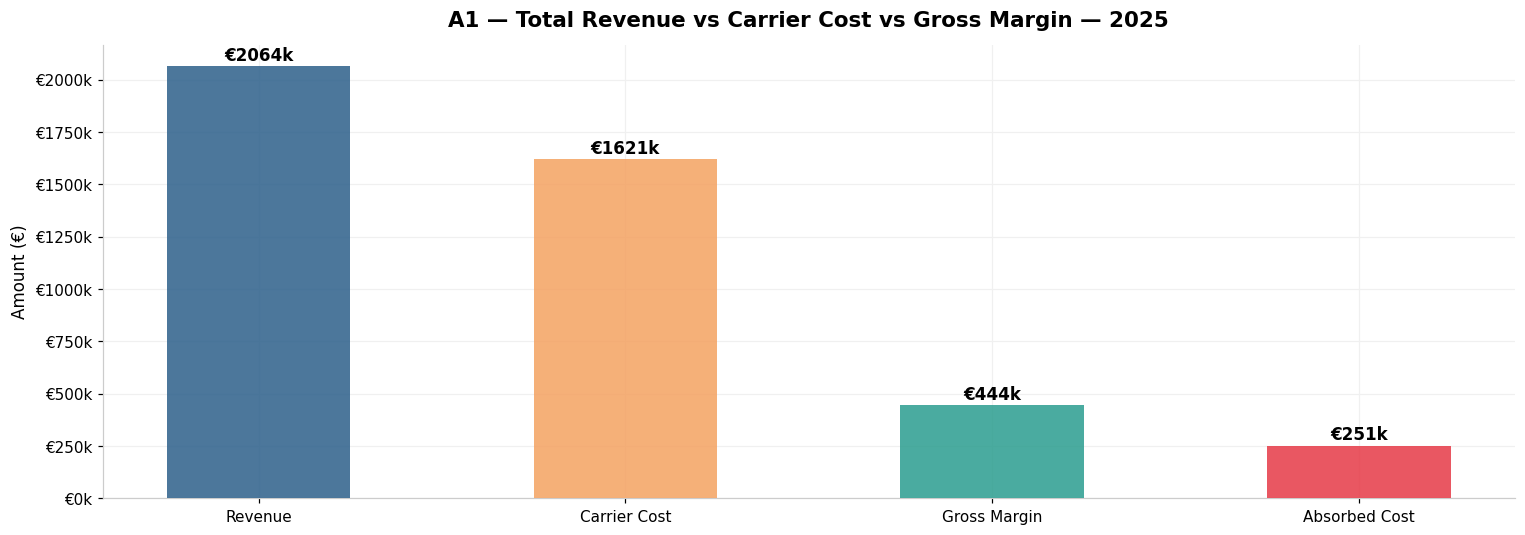

In [7]:
# ── A1: Total revenue vs cost vs margin ──────────────────────────────────────
total_revenue = matched["rever_revenue_net"].sum()
total_cost    = matched["carrier_cost_net"].sum()
total_margin  = matched["margin_eur"].sum()
margin_pct    = total_margin / total_revenue * 100

# Unmatched cost = carrier billed REVER but REVER didn't charge merchant
unmatched_cost = merged.loc[merged["rever_revenue_net"].isna(), "carrier_cost_net"].sum()

print("─" * 45)
print(f"  Total revenue (billed to merchants) : €{total_revenue:>12,.0f}")
print(f"  Total carrier cost (matched)        : €{total_cost:>12,.0f}")
print(f"  Gross margin                        : €{total_margin:>12,.0f}  ({margin_pct:.1f}%)")
print(f"  Absorbed cost (unmatched shipments) : €{unmatched_cost:>12,.0f}")
print("─" * 45)

labels  = ["Revenue", "Carrier Cost", "Gross Margin", "Absorbed Cost"]
values  = [total_revenue, total_cost, total_margin, unmatched_cost]
colors  = [PALETTE["primary"], PALETTE["accent"], PALETTE["positive"], PALETTE["negative"]]

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
bars = ax.bar(labels, values, color=colors, alpha=0.85, zorder=3, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total_revenue * 0.005,
            f"€{val/1_000:.0f}k", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1_000:.0f}k"))
ax.set_title("A1 — Total Revenue vs Carrier Cost vs Gross Margin — 2025", pad=12)
ax.set_ylabel("Amount (€)")
plt.tight_layout()
plt.show()

---
## A2 — Average margin per shipment

Average margin in € and % per shipment. Then: does higher volume correlate with better or worse margin per shipment?
If margin per shipment drops as volume grows, carriers are not passing volume discounts to REVER (or REVER is not adjusting pricing upward).

Average margin per shipment : €1.82
Median margin %             :  16.4%


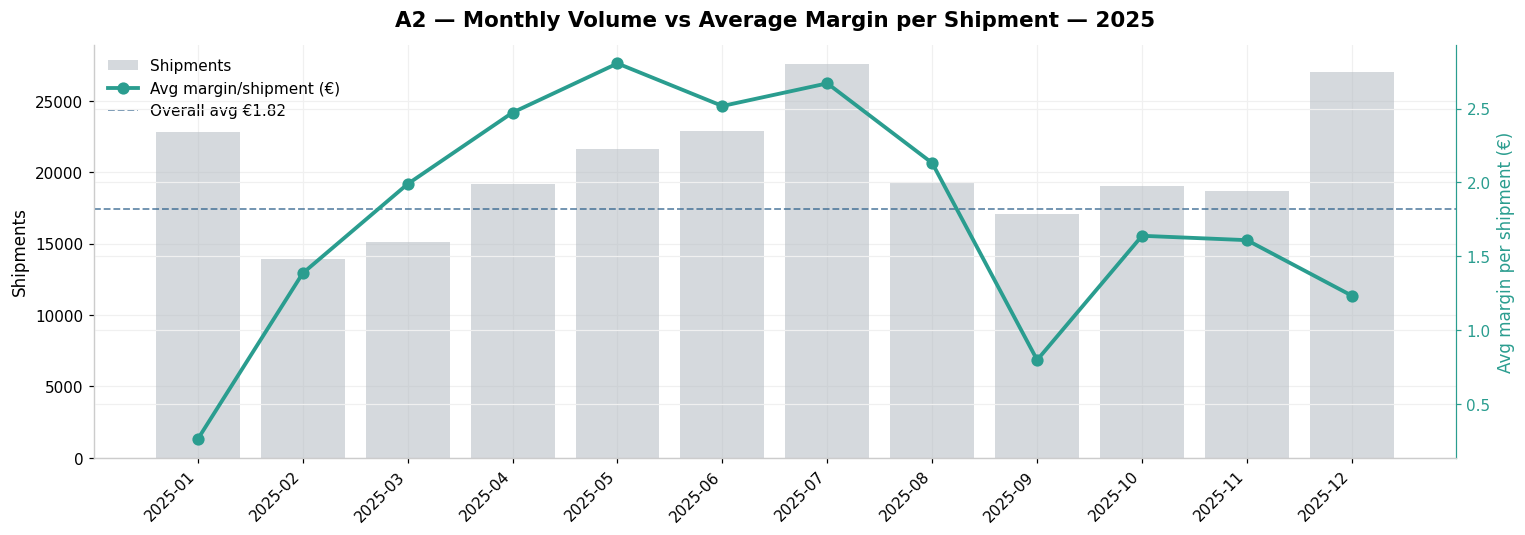

In [8]:
# ── A2: Average margin per shipment ──────────────────────────────────────────
avg_margin_eur = matched["margin_eur"].mean()
avg_margin_pct = matched["margin_pct"].median()  # median avoids outlier distortion

print(f"Average margin per shipment : €{avg_margin_eur:.2f}")
print(f"Median margin %             :  {avg_margin_pct:.1f}%")

# Monthly: volume vs average margin per shipment
monthly = (
    matched.groupby("month")
    .agg(shipments=("tracking_id", "count"), avg_margin=("margin_eur", "mean"))
    .sort_index()
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(FIG_W, FIG_H))
ax2 = ax1.twinx()

ax1.bar(monthly["month"], monthly["shipments"],
        color=PALETTE["neutral"], alpha=0.5, label="Shipments", zorder=2)
ax2.plot(monthly["month"], monthly["avg_margin"],
         marker="o", color=PALETTE["positive"] if monthly["avg_margin"].mean() > 0 else PALETTE["negative"],
         linewidth=2.5, markersize=7, label="Avg margin/shipment (€)", zorder=3)
ax2.axhline(avg_margin_eur, color=PALETTE["primary"], linewidth=1.2,
            linestyle="--", alpha=0.7, label=f"Overall avg €{avg_margin_eur:.2f}")

ax1.set_ylabel("Shipments")
ax2.set_ylabel("Avg margin per shipment (€)", color=PALETTE["positive"])
ax2.tick_params(axis="y", colors=PALETTE["positive"])
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color(PALETTE["positive"])
ax1.set_xticklabels(monthly["month"], rotation=45, ha="right")

lines1, lbls1 = ax1.get_legend_handles_labels()
lines2, lbls2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbls1 + lbls2, loc="upper left")
ax1.set_title("A2 — Monthly Volume vs Average Margin per Shipment — 2025", pad=12)
plt.tight_layout()
plt.show()

---
## A3 — Price vs Cost evolution

Are REVER's prices to merchants rising at the same pace as carrier costs?
If carrier cost grows faster than revenue per shipment, margin is being compressed month by month.

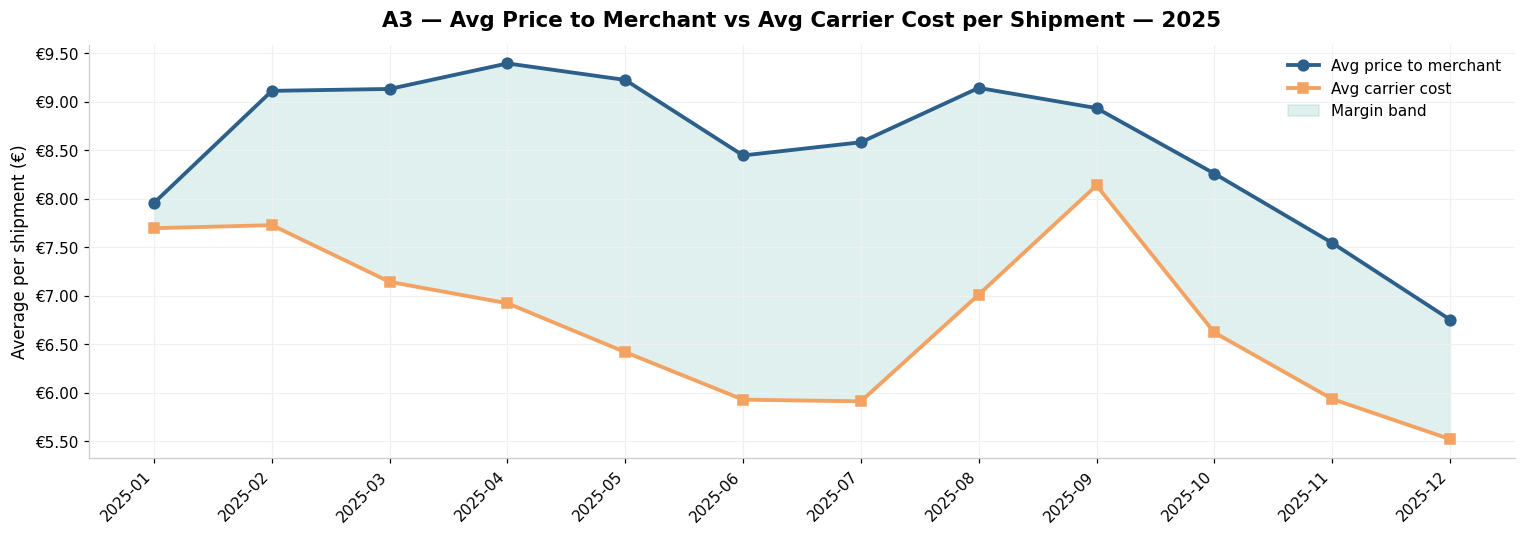

In [9]:
# ── A3: Monthly avg revenue/shipment vs avg carrier cost/shipment ─────────────
price_vs_cost = (
    matched.groupby("month")
    .agg(
        avg_price = ("rever_revenue_net", "mean"),
        avg_cost  = ("carrier_cost_net",  "mean"),
    )
    .sort_index()
    .reset_index()
)
price_vs_cost["avg_margin"] = price_vs_cost["avg_price"] - price_vs_cost["avg_cost"]

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(price_vs_cost["month"], price_vs_cost["avg_price"],
        marker="o", color=PALETTE["primary"], linewidth=2.5, markersize=7, label="Avg price to merchant")
ax.plot(price_vs_cost["month"], price_vs_cost["avg_cost"],
        marker="s", color=PALETTE["accent"], linewidth=2.5, markersize=7, label="Avg carrier cost")
ax.fill_between(price_vs_cost["month"],
                price_vs_cost["avg_cost"], price_vs_cost["avg_price"],
                alpha=0.15,
                color=PALETTE["positive"] if price_vs_cost["avg_margin"].mean() > 0 else PALETTE["negative"],
                label="Margin band")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:.2f}"))
ax.set_xticklabels(price_vs_cost["month"], rotation=45, ha="right")
ax.set_ylabel("Average per shipment (€)")
ax.legend()
ax.set_title("A3 — Avg Price to Merchant vs Avg Carrier Cost per Shipment — 2025", pad=12)
plt.tight_layout()
plt.show()

---
## A4 — Anomaly detection (zero price / zero cost)

Shipments with `carrier_cost_net = 0` but a REVER revenue entry, or with REVER revenue `= 0` but a real carrier cost.
These are guaranteed-loss shipments or data integrity issues — both need to be quantified.

                    Type  Count  Total cost impact (€)
     Cost = 0 (data gap)      0                 0.0000
Revenue = 0 (free/error)     33              2025.7600
       Margin < 0 (loss)  56035           -240578.3533


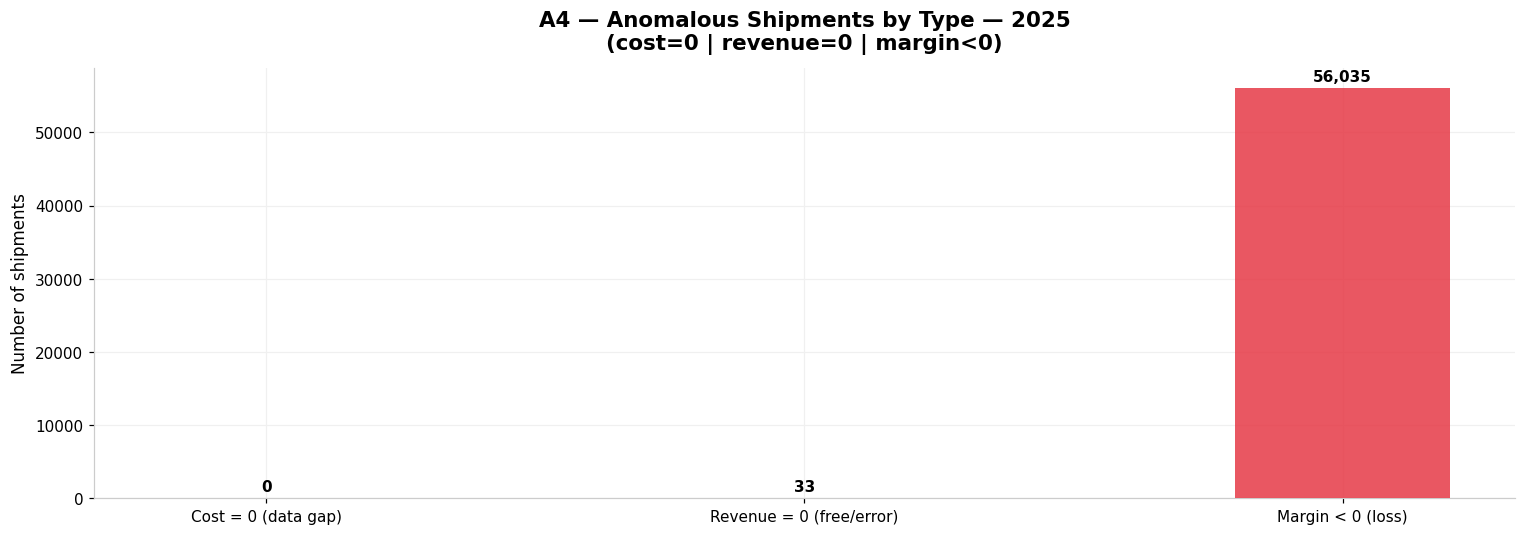

In [10]:
# ── A4: Anomaly detection ─────────────────────────────────────────────────────
# Type 1: Revenue present, but carrier cost = 0 → data gap (no carrier invoice)
# Type 2: Carrier cost present, but revenue = 0  → REVER billed merchant €0 (free shipment / error)
# Type 3: Both present, margin < 0               → REVER lost money on this shipment

type1 = matched[matched["carrier_cost_net"] <= 0]
type2 = matched[matched["rever_revenue_net"] <= 0]
type3 = matched[matched["margin_eur"] < 0]

anomaly_summary = pd.DataFrame({
    "Type": ["Cost = 0 (data gap)", "Revenue = 0 (free/error)", "Margin < 0 (loss)"],
    "Count": [len(type1), len(type2), len(type3)],
    "Total cost impact (€)": [
        type1["rever_revenue_net"].sum(),
        type2["carrier_cost_net"].sum(),
        type3["margin_eur"].sum(),
    ],
})
print(anomaly_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
colors_anom = [PALETTE["neutral"], PALETTE["accent"], PALETTE["negative"]]
bars = ax.bar(anomaly_summary["Type"], anomaly_summary["Count"],
              color=colors_anom, alpha=0.85, zorder=3, width=0.4)

for bar, row in zip(bars, anomaly_summary.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(anomaly_summary["Count"]) * 0.01,
            f"{row.Count:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Number of shipments")
ax.set_title("A4 — Anomalous Shipments by Type — 2025\n(cost=0 | revenue=0 | margin<0)", pad=12)
plt.tight_layout()
plt.show()

---
## A5 — True effective margin

The 21.5% gross margin is computed on matched shipments only.
Two additional cost layers reduce the real margin:
1. Absorbed carrier cost (shipments REVER paid for but never billed to merchant)
2. BRT: total cost known from invoices, revenue estimated from REVER-only records (H2)

This cell shows the waterfall from gross margin → effective margin → conservative net.

────────────────────────────────────────────────────────────
  Gross margin (matched, 21.5%)              : €   443,751
  Less: absorbed carrier cost (H1)           : €  -250,647
  ─────────────────────────────────────────────────────
  Effective margin (excl. absorbed)          : €   193,104  (9.4%)

  BRT carrier cost (unreconciled)            : €  -200,475
  BRT revenue (REVER-only estimate, H2)      : €   319,797
  BRT estimated net contribution             : €   119,322
  ─────────────────────────────────────────────────────
  Conservative total net margin              : €   312,426  (13.1%)
────────────────────────────────────────────────────────────


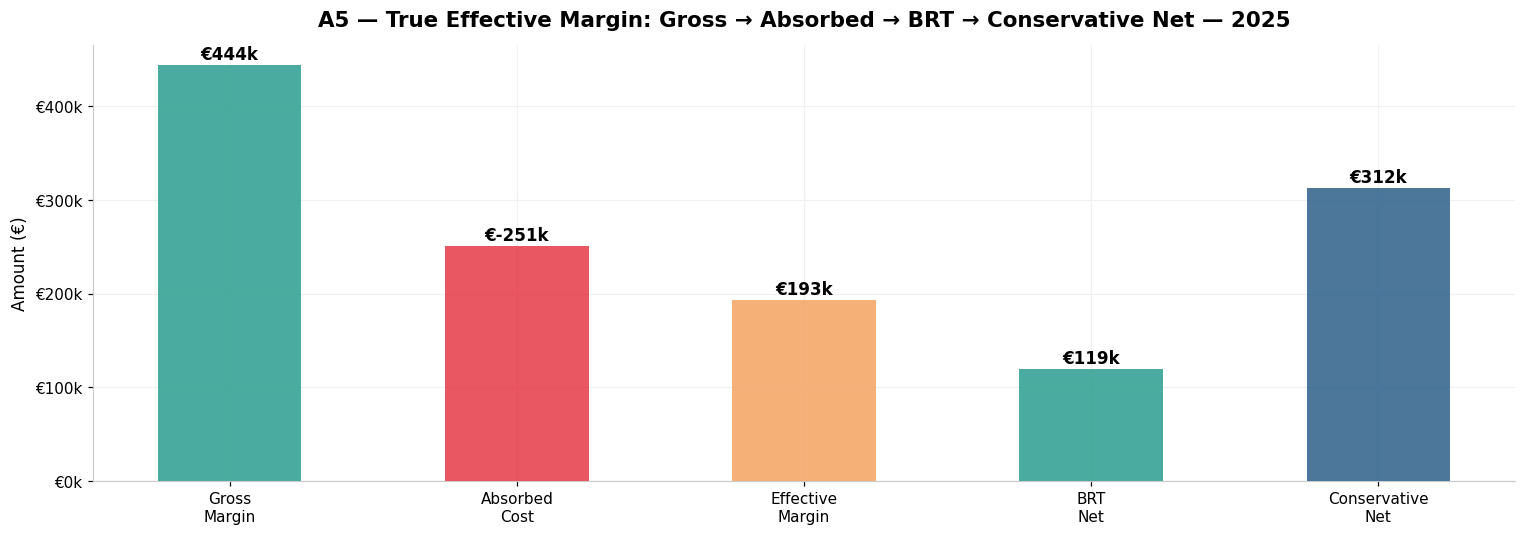

In [11]:
# ── A5: True effective margin ──────────────────────────────────────────────────
gross_margin  = matched["margin_eur"].sum()
total_revenue = matched["rever_revenue_net"].sum()
absorbed_cost = merged.loc[merged["rever_revenue_net"].isna(), "carrier_cost_net"].sum()

# BRT figures from 01_preparacion (cost) and H2 (REVER-only revenue, likely BRT)
BRT_COST    = 200_475
BRT_REVENUE = 319_797
brt_net     = BRT_REVENUE - BRT_COST

effective_margin     = gross_margin - absorbed_cost
effective_margin_pct = effective_margin / total_revenue * 100

conservative_margin     = effective_margin + brt_net
conservative_margin_pct = conservative_margin / (total_revenue + BRT_REVENUE) * 100

print("─" * 60)
print(f"  Gross margin (matched, 21.5%)              : €{gross_margin:>10,.0f}")
print(f"  Less: absorbed carrier cost (H1)           : €{-absorbed_cost:>10,.0f}")
print(f"  ─────────────────────────────────────────────────────")
print(f"  Effective margin (excl. absorbed)          : €{effective_margin:>10,.0f}  ({effective_margin_pct:.1f}%)")
print()
print(f"  BRT carrier cost (unreconciled)            : €{-BRT_COST:>10,.0f}")
print(f"  BRT revenue (REVER-only estimate, H2)      : €{BRT_REVENUE:>10,.0f}")
print(f"  BRT estimated net contribution             : €{brt_net:>10,.0f}")
print(f"  ─────────────────────────────────────────────────────")
print(f"  Conservative total net margin              : €{conservative_margin:>10,.0f}  ({conservative_margin_pct:.1f}%)")
print("─" * 60)

# Waterfall chart
labels = ["Gross\nMargin", "Absorbed\nCost", "Effective\nMargin", "BRT\nNet", "Conservative\nNet"]
values = [gross_margin, -absorbed_cost, effective_margin, brt_net, conservative_margin]
colors = [PALETTE["positive"], PALETTE["negative"], PALETTE["accent"],
          PALETTE["positive"] if brt_net > 0 else PALETTE["negative"], PALETTE["primary"]]

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
bars = ax.bar(labels, [abs(v) for v in values], color=colors, alpha=0.85, zorder=3, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2_000,
            f"€{val/1_000:.0f}k", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1_000:.0f}k"))
ax.set_title("A5 — True Effective Margin: Gross → Absorbed → BRT → Conservative Net — 2025", pad=12)
ax.set_ylabel("Amount (€)")
plt.tight_layout()
plt.show()

---
## A6 — Negative-margin shipments deep dive

56,035 shipments (22.9%) have margin < 0. This is not statistical noise — it is a systematic pricing failure.
Breakdown by carrier, month, and merchant to identify the root cause.

Negative-margin shipments : 56,035 (23.0% of matched)
Total loss                : €-240,578

By carrier:
                 count   total_loss   avg_loss
carrier                                       
UPS              16485 -208452.8633 -12.645002
Correos          30536  -20772.3900  -0.680259
Correos Express   9014  -11353.1000  -1.259496

By month:
         count  total_loss
month                     
2025-01   7237 -40917.0699
2025-02   3659 -16443.7248
2025-03   3586 -10590.2582
2025-04   3321 -11735.1483
2025-05   3809 -12486.1317
2025-06   4323 -12941.7980
2025-07   5121 -16652.6862
2025-08   4302 -22645.6340
2025-09   4188 -36044.1660
2025-10   4649 -21570.0762
2025-11   4414 -17449.7489
2025-12   7426 -21101.9111

Top 10 merchants by total loss:
                    count  total_loss   avg_loss
stripe_cust_id                                  
cus_OL8Hghw8fC6VbF   1237 -36109.0200 -29.190800
cus_PqmcALHs2lmPww    619 -23799.6168 -38.448492
cus_QPZ2d6cXHBzdQP    564 -16777.4700 -29.

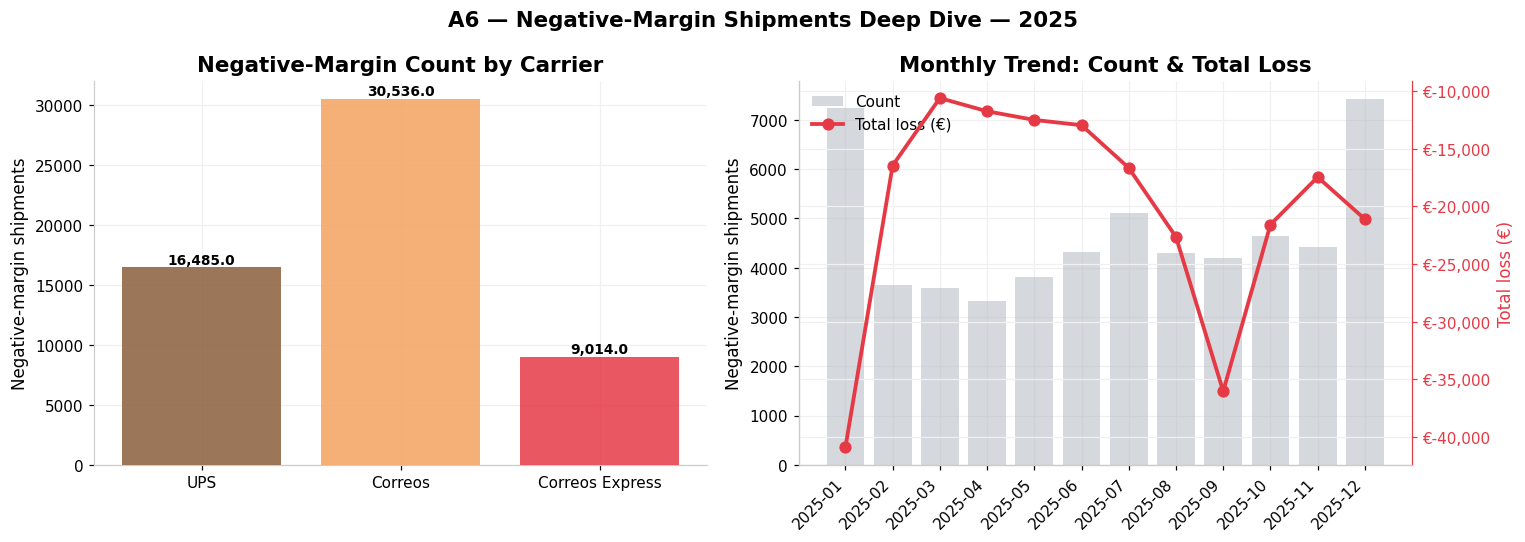

In [12]:
# ── A6: Negative-margin shipments — deep dive ─────────────────────────────────
neg = matched[matched["margin_eur"] < 0].copy()

print(f"Negative-margin shipments : {len(neg):,} ({len(neg)/len(matched)*100:.1f}% of matched)")
print(f"Total loss                : €{neg['margin_eur'].sum():,.0f}")
print()

# By carrier
by_carrier = (
    neg.groupby("carrier")
    .agg(count=("tracking_id", "count"),
         total_loss=("margin_eur", "sum"),
         avg_loss=("margin_eur", "mean"))
    .sort_values("total_loss")
)
print("By carrier:")
print(by_carrier.to_string())
print()

# By month
by_month = (
    neg.groupby("month")
    .agg(count=("tracking_id", "count"), total_loss=("margin_eur", "sum"))
    .sort_index()
)
print("By month:")
print(by_month.to_string())
print()

# Top 10 merchants by total loss
by_merchant = (
    neg.groupby("stripe_cust_id")
    .agg(count=("tracking_id", "count"),
         total_loss=("margin_eur", "sum"),
         avg_loss=("margin_eur", "mean"))
    .sort_values("total_loss")
    .head(10)
)
print("Top 10 merchants by total loss:")
print(by_merchant.to_string())

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# Left: negative shipment count by carrier
colors_neg = [CARRIER_COLORS.get(c, PALETTE["neutral"]) for c in by_carrier.index]
axes[0].bar(by_carrier.index, by_carrier["count"], color=colors_neg, alpha=0.85, zorder=3)
axes[0].set_title("Negative-Margin Count by Carrier")
axes[0].set_ylabel("Negative-margin shipments")
for i, (c, row) in enumerate(by_carrier.iterrows()):
    axes[0].text(i, row["count"] + max(by_carrier["count"]) * 0.01,
                 f"{row['count']:,}", ha="center", fontsize=9, fontweight="bold")

# Right: monthly count + total loss trend
ax2 = axes[1]
ax2b = ax2.twinx()
ax2.bar(by_month.index, by_month["count"],
        color=PALETTE["neutral"], alpha=0.5, label="Count", zorder=2)
ax2b.plot(by_month.index, by_month["total_loss"],
          marker="o", color=PALETTE["negative"], linewidth=2.5, markersize=7,
          label="Total loss (€)", zorder=3)
ax2.set_ylabel("Negative-margin shipments")
ax2b.set_ylabel("Total loss (€)", color=PALETTE["negative"])
ax2b.tick_params(axis="y", colors=PALETTE["negative"])
ax2b.spines["right"].set_visible(True)
ax2b.spines["right"].set_color(PALETTE["negative"])
ax2.set_xticklabels(by_month.index, rotation=45, ha="right")
ax2b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:,.0f}"))
ax2.set_title("Monthly Trend: Count & Total Loss")

lines1, lbs1 = ax2.get_legend_handles_labels()
lines2, lbs2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, lbs1 + lbs2, loc="upper left")

fig.suptitle("A6 — Negative-Margin Shipments Deep Dive — 2025", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()